<a href="https://colab.research.google.com/github/adrianhernr/QuantumAlgorithms/blob/main/QFT%20Period.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit
!pip install qiskit_aer

/tmp/ipykernel_2081/3971938787.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft_gate = QFT(num_qubits=n_entrada, inverse=True).to_gate()


     ┌───┐                ┌───────┐┌─┐      
q_0: ┤ H ├─■──────────────┤0      ├┤M├──────
     ├───┤ │              │       │└╥┘┌─┐   
q_1: ┤ H ├─┼────────■─────┤1 IQFT ├─╫─┤M├───
     ├───┤ │        │     │       │ ║ └╥┘┌─┐
q_2: ┤ H ├─┼────────┼─────┤2      ├─╫──╫─┤M├
     ├───┤ │P(π/2)  │P(π) └───────┘ ║  ║ └╥┘
q_3: ┤ X ├─■────────■───────────────╫──╫──╫─
     └───┘                          ║  ║  ║ 
q_4: ───────────────────────────────╫──╫──╫─
                                    ║  ║  ║ 
q_5: ───────────────────────────────╫──╫──╫─
                                    ║  ║  ║ 
c: 3/═══════════════════════════════╩══╩══╩═
                                    0  1  2 


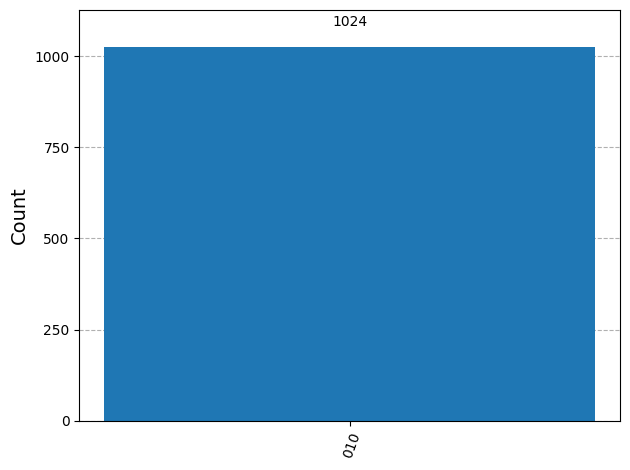

In [8]:
import numpy as np
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
# Importamos la librería nativa de QFT
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# 1. Definición del circuito (6 qubits en total)
n_entrada = 3
n_funcion = 3
qr = QuantumRegister(n_entrada + n_funcion, 'q')
cr = ClassicalRegister(n_entrada, 'c')
qc = QuantumCircuit(qr, cr)

# 2. Inicialización
# Estado de superposición en el registro de entrada
qc.h(qr[:n_entrada])
# Preparar el estado |1> en el registro de la función
qc.x(qr[n_entrada])

# 3. Oráculo (Función Periódica)
# Simulación de desplazamientos controlados
qc.cp(np.pi/2, qr[0], qr[n_entrada])
qc.cp(np.pi, qr[1], qr[n_entrada])

# 4. QFT Inversa usando la librería de Qiskit
# Creamos la QFT para 'n_entrada' qubits, la invertimos y la hacemos circuito
iqft_gate = QFT(num_qubits=n_entrada, inverse=True).to_gate()
# La añadimos al circuito principal aplicándola sobre los qubits de entrada
qc.append(iqft_gate, qr[:n_entrada])

# 5. Medición
qc.measure(qr[:n_entrada], cr)

# Visualización del circuito
print(qc.draw())

# 6. Ejecución en el simulador local de Aer
conversor = AerSimulator()
qc_compilado = transpile(qc, backend=conversor)

job = conversor.run(qc_compilado, shots=1024)
resultado = job.result()

# 7. Obtener los conteos e imprimirlos
conteos = resultado.get_counts()
plot_histogram(conteos)

# Opcional: Si estás en un Jupyter Notebook para ver la gráfica
# plot_histogram(conteos)
